In [48]:
import numpy as np
import networkx as nx
import asymmetree.treeevolve as te
import asymmetree.analysis.best_matches as bm
from BICcherry import BICcherry as BC
from BICcherryRestrict import BICcherryRestrict as BCR
import tralda
import random
from collections import defaultdict

np.random.seed(1)
random.seed(1)

          a       b       c       d       e       f
 0.00  -0.41   -0.41   -0.41   -0.41   -0.41   -0.41
 0.44  -0.46   -0.46   -0.26    0.26    0.46    0.46
 3.00   0.76   -0.61   -0.15   -0.15    0.08    0.08
 3.00   0.00   -0.00    0.00    0.00   -0.71    0.71
 3.00   0.09    0.46   -0.56   -0.56    0.28    0.28
 4.56  -0.18   -0.18    0.66   -0.66    0.18    0.18


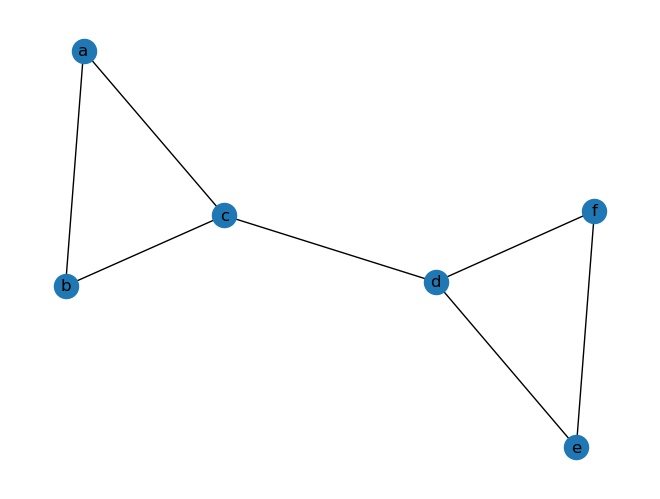

In [40]:
# toy: two triangles joined by a bridge
U = nx.Graph([('a','b'),('b','c'),('a','c'),
              ('c','d'),                     # the bridge
              ('d','e'),('e','f'),('d','f')])

nx.draw(U, with_labels=True)
nodes = list(U.nodes)
L = nx.laplacian_matrix(U, nodelist=nodes).toarray()
w, V = np.linalg.eigh(L)

print('     ' + '  '.join(f'{n:>6}' for n in nodes))
for k in range(len(nodes)):
    print(f'{w[k]:5.2f} ' + '  '.join(f'{V[i,k]:6.2f}' for i in range(len(nodes))))

          a       b       c      b+       d       e       f
-0.00  -0.38   -0.38   -0.38   -0.38   -0.38   -0.38   -0.38
 0.34   0.51    0.34    0.11    0.27   -0.31   -0.47   -0.47
 1.15  -0.71    0.10    0.36    0.54    0.02   -0.16   -0.16
 3.00  -0.00    0.00   -0.50    0.50   -0.50    0.49    0.01
 3.00  -0.00    0.00   -0.18    0.18   -0.18   -0.57    0.76
 3.85  -0.26    0.75    0.06   -0.44   -0.37    0.13    0.13
 4.66  -0.11    0.40   -0.65    0.09    0.59   -0.16   -0.16


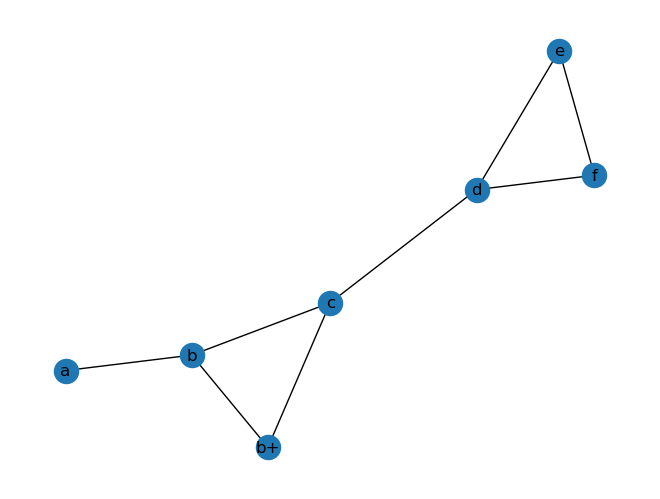

In [41]:
U = nx.Graph([('a','b'),('b','c'),('b','b+'),('c','b+'),
              ('c','d'),                     # the bridge
              ('d','e'),('e','f'),('d','f')])

nx.draw(U, with_labels=True)
nodes = list(U.nodes)
L = nx.laplacian_matrix(U, nodelist=nodes).toarray()
w, V = np.linalg.eigh(L)

print('     ' + '  '.join(f'{n:>6}' for n in nodes))
for k in range(len(nodes)):
    print(f'{w[k]:5.2f} ' + '  '.join(f'{V[i,k]:6.2f}' for i in range(len(nodes))))

         A1      A2      A3      B1      B2      B3      C1      C2      C3
-0.00  -0.33   -0.33   -0.33   -0.33   -0.33   -0.33   -0.33   -0.33   -0.33
 0.21   0.43    0.43    0.34    0.09   -0.00   -0.09   -0.34   -0.43   -0.43
 0.70   0.29    0.29    0.09   -0.38   -0.59   -0.38    0.09    0.29    0.29
 3.00  -0.01    0.03   -0.03   -0.03   -0.48    0.51    0.51   -0.50   -0.01
 3.00   0.76   -0.56   -0.20   -0.20    0.14    0.06    0.06   -0.03   -0.03
 3.00   0.00   -0.08    0.08    0.08    0.12   -0.20   -0.20   -0.56    0.76
 3.00   0.00    0.51   -0.51   -0.51    0.42    0.09    0.09   -0.14    0.05
 4.30   0.16    0.16   -0.52    0.36   -0.31    0.36   -0.52    0.16    0.16
 4.79  -0.11   -0.11    0.43   -0.54   -0.00    0.54   -0.43    0.11    0.11


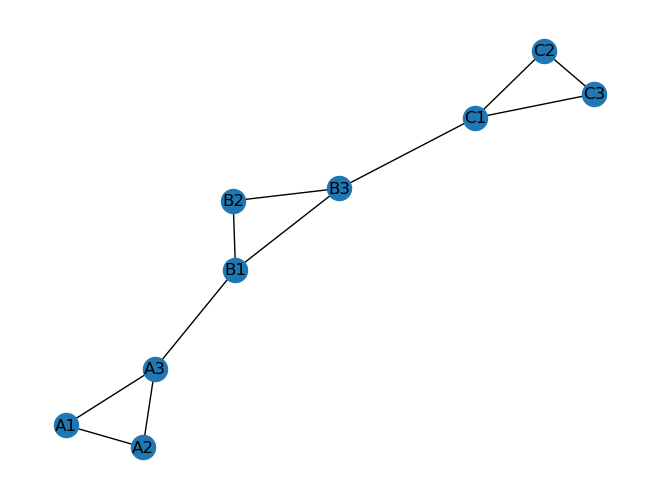

In [12]:
tri = lambda p: [(p+'1',p+'2'),(p+'2',p+'3'),(p+'1',p+'3')]
U = nx.Graph(tri('A') + tri('B') + tri('C') + [('A3','B1'), ('B3','C1')])
# ring: add ('C3','A1')
nx.draw(U, with_labels=True)
nodes = list(U.nodes)
L = nx.laplacian_matrix(U, nodelist=nodes).toarray()
w, V = np.linalg.eigh(L)

print('     ' + '  '.join(f'{n:>6}' for n in nodes))
for k in range(len(nodes)):
    print(f'{w[k]:5.2f} ' + '  '.join(f'{V[i,k]:6.2f}' for i in range(len(nodes))))

True
        rho   p_4_6       4       6   p_4_7       7   p_3_6       3   p_3_7   p_3_4
-1.06   0.00    0.00   -0.51   -0.00   -0.17   -0.28   -0.00   -0.64   -0.30   -0.37
-0.60   0.00    0.00    0.66   -0.00    0.26   -0.53   -0.00   -0.30   -0.32    0.14
-0.41  -0.00   -0.00   -0.00   -0.92   -0.00    0.00   -0.38    0.00    0.00   -0.00
-0.09   0.00    0.00   -0.32   -0.00   -0.15   -0.72   -0.00    0.58   -0.07    0.12
 2.00   0.00    1.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00
 2.09   0.00    0.00    0.07   -0.00   -0.72    0.15    0.00   -0.12   -0.32    0.58
 2.41   0.00    0.00    0.00    0.38   -0.00   -0.00   -0.92   -0.00   -0.00    0.00
 2.60   0.00    0.00   -0.32    0.00    0.53    0.26   -0.00    0.14   -0.66    0.30
 3.06   0.00    0.00   -0.30    0.00    0.28   -0.17   -0.00   -0.37    0.51    0.64
 5.00   1.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00


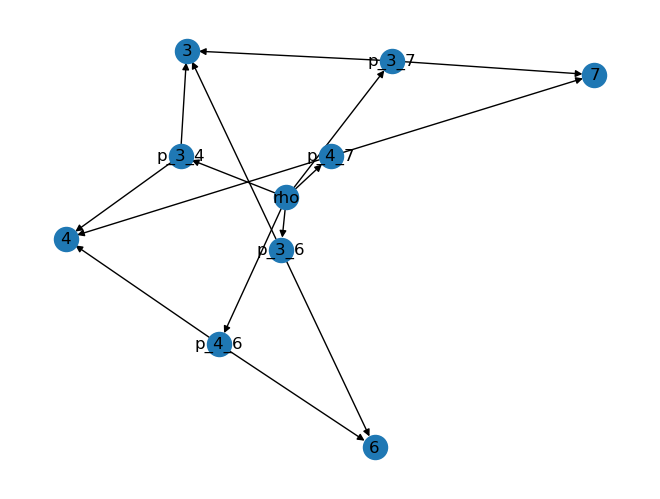

In [54]:
# species tree
ST=te.species_tree_n(3)
# gene tree
GT=te.dated_gene_tree(ST, dupl_rate=.2,)

## optimize leaf count
while True:
    GT = te.prune_losses(te.dated_gene_tree(ST, dupl_rate=.2))
    if 4 <= len(list(GT.leaves())) <= 6: break

#BMG
BMG = bm.bmg_from_tree(GT)

#LRT from gene tree
LRT = bm.lrt_from_tree(GT)

#LRT from BMG
BMG_LRT = bm.lrt_from_colored_graph(BMG)

## test isomorphism
print(LRT.equal_topology(BMG_LRT))

#Build Network N via BC from BMG
N = BC(BMG)



        rho   p_4_6       4       6   p_4_7       7   p_3_6       3   p_3_7   p_3_4
 0.00  -0.32   -0.32   -0.32   -0.32   -0.32   -0.32   -0.32   -0.32   -0.32   -0.32
 1.00   0.00   -0.29    0.00   -0.58    0.29    0.58   -0.29   -0.00    0.29    0.00
 1.59  -0.00   -0.35   -0.50   -0.00   -0.35    0.00    0.35    0.50    0.35   -0.00
 1.71   0.08   -0.07    0.31   -0.49   -0.07   -0.49   -0.07    0.31   -0.07    0.55
 3.00   0.00    0.50   -0.00   -0.00   -0.50   -0.00   -0.50    0.00    0.50   -0.00
 3.40  -0.36   -0.27    0.08    0.39   -0.27    0.39   -0.27    0.08   -0.27    0.51
 4.00   0.50   -0.02   -0.50    0.02    0.02   -0.02   -0.02   -0.50    0.02    0.50
 4.00  -0.02   -0.41    0.02    0.41    0.41   -0.41   -0.41    0.02    0.41   -0.02
 4.41   0.00   -0.35    0.50    0.00   -0.35   -0.00    0.35   -0.50    0.35    0.00
 6.90   0.72   -0.27    0.21    0.11   -0.27    0.11   -0.27    0.21   -0.27   -0.29


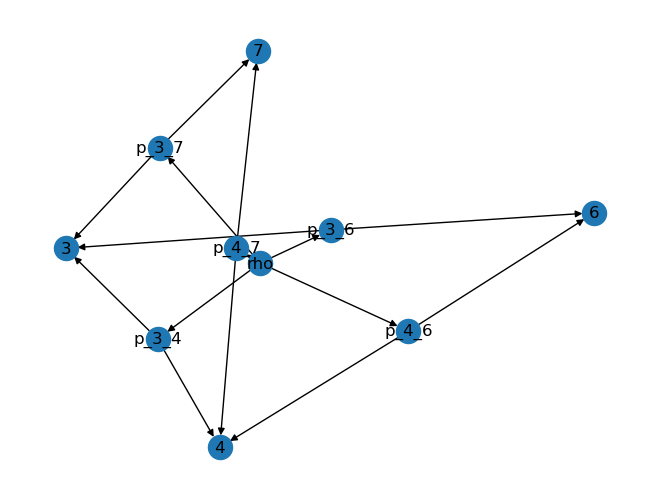

In [60]:
# Spectral Decomp
nx.draw(N, with_labels=True, node_color=)
U = N.to_undirected()
nodes = list(U.nodes)
L = nx.laplacian_matrix(U, nodelist=nodes).toarray()
w, V = np.linalg.eigh(L)

print('     ' + '  '.join(f'{n:>6}' for n in nodes))
for k in range(len(nodes)):
    print(f'{w[k]:5.2f} ' + '  '.join(f'{V[i,k]:6.2f}' for i in range(len(nodes))))

In [56]:
print(V)

[[ 0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-5.09305062e-01  6.64427371e-01 -7.15206937e-16 -3.20823328e-01
   0.00000000e+00  6.81669621e-02  2.52245622e-16 -3.18857698e-01
  -2.99833369e-01  0.00000000e+00]
 [-2.22044605e-16 -1.27675648e-15 -9.23879533e-01 -3.95516953e-16
   0.00000000e+00 -3.33066907e-16  3.82683432e-01  2.22044605e-16
   1.11022302e-16  0.00000000e+00]
 [-1.66394966e-01  2.55704020e-01 -3.75850344e-16 -1.53169774e-01
   0.00000000e+00 -7.20883474e-01 -9.81880459e-16  5.32829381e-01
   2.82642986e-01  0.00000000e+00]
 [-2.82642986e-01 -5.32829381e-01  9.87105290e-16 -7.20883474e-01
   0.00000000e+00  1.53169774e-01 -9.12219452e-17  2.55704020e-01
  -1.66394966e-01  0.00000000e+00

tree: 2.4424906541753444e-14  +1 retic: -7.667
N: -746.714  retic: 42
N leaves-only: -27.71


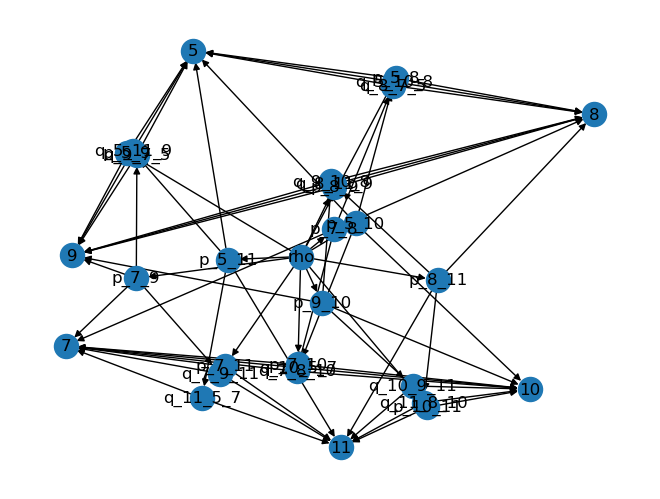

In [49]:
def effective_resistance(U: nx.Graph, nodes: list) -> np.ndarray:
    """R[i,j] = effective resistance between nodes[i], nodes[j] (unit resistors on edges)."""
    L = nx.laplacian_matrix(U, nodelist=nodes).toarray().astype(float)
    Lp = np.linalg.pinv(L)
    d = np.diag(Lp)
    return d[:, None] + d[None, :] - 2 * Lp


def path_minus_resistance(G: nx.DiGraph, leaves_only: bool = False) -> float:
    """Tree-likeness score, higher = more tree-like, 0 iff G's underlying graph is a tree.

    -sum over pairs of (shortest path length - effective resistance).
    d == R exactly when there is a unique path; every cycle makes R < d.
    """
    U = G.to_undirected()
    nodes = list(U.nodes)
    R = effective_resistance(U, nodes)
    sp = dict(nx.all_pairs_shortest_path_length(U))
    idx = [i for i, v in enumerate(nodes) if (not leaves_only) or G.out_degree(v) == 0]
    return -sum(sp[nodes[i]][nodes[j]] - R[i, j]
                for a, i in enumerate(idx) for j in idx[a + 1:])

def reticulation_number(G: nx.DiGraph) -> int:
    return G.number_of_edges() - G.number_of_nodes() + 1

ST = te.species_tree_n(3)
while True:
    GT = te.prune_losses(te.dated_gene_tree(ST, dupl_rate=.2))
    if 4 <= len(list(GT.leaves())) <= 6:
        break
BMG = bm.bmg_from_tree(GT)
LRT = bm.lrt_from_tree(GT)
T, root = LRT.to_nx()

# sanity 1: tree scores 0
assert abs(path_minus_resistance(T)) < 1e-9

# sanity 2: one reticulation edge -> negative
leaves = [v for v in T if T.out_degree(v) == 0]
T2 = T.copy()
T2.add_edge(root, next(l for l in leaves if not T2.has_edge(root, l)))
assert path_minus_resistance(T2) < -1e-9
print("tree:", path_minus_resistance(T), " +1 retic:", round(path_minus_resistance(T2), 3))

# on the BIC-cherry network:
from BICcherry import BICcherry as BC
N = BC(BMG)
print("N:", round(path_minus_resistance(N), 3), " retic:", reticulation_number(N))
print("N leaves-only:", round(path_minus_resistance(N, leaves_only=True), 3))

nx.draw(N, with_labels=True)